<div style="
  background-color:#CD5C5C;
  padding:20px;
  border-radius:12px;
  text-align:center;
  color:white;
  margin-bottom:20px;
">

  <h1 style="margin:0;">
    Cheks_coherence — Analyse e-commerce
  </h1>

  <p style="margin:5px 0 0 0; font-size:16px;">
    Notebook 02 : Analyse comparative des kpi
  </p>

</div>

In [1]:
"""
Configuration de l'environnement — Analyse e-commerce
===================================================
Imports et configuration pour l'analyse exploratoire des données.
"""

import os
import sys

# Manipulation des données
import pandas as pd
import numpy as np

# Statistiques et tests
import scipy.stats as ss

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Seed pour la reproductibilité
RANDOM_STATE = 1204

# Import de la fonction utilitaire depuis utils/data_prep.py
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.data_prep import detect_possible_outliers

print(f" Imports chargés avec succès")

 Imports chargés avec succès


In [2]:
# Vérification du répertoire de travail
print(f" Répertoire courant : {os.getcwd()}")

 Répertoire courant : c:\Users\juber\Documents\Analyse-e-commerce-GCP-BigQuery\notebooks


In [3]:
# Chargement du dataset depuis le fichier CSV
df_eda = pd.read_csv('../data/thelook_fr_women_2023_2024.csv')

# Chargement du dataset depuis BigQuery
df_sql = pd.read_csv('../data/dataset_reconstruction.csv')

In [4]:
col_list = df_eda.columns.tolist()
print(f" Colonnes du dataset : {len(col_list)} colonnes\n{col_list}")

 Colonnes du dataset : 20 colonnes
['order_id', 'order_item_id', 'product_id', 'item_created_at', 'item_status', 'sale_price', 'cost', 'category', 'department', 'brand', 'product_name', 'order_status', 'order_created_at', 'shipped_at', 'delivered_at', 'user_id', 'gender', 'country', 'state', 'city']


In [5]:
col_list_sql = df_sql.columns.tolist()
print(f" Colonnes du dataset SQL : {len(col_list_sql)} colonnes\n{col_list_sql}")

 Colonnes du dataset SQL : 16 colonnes
['item_date', 'order_date', 'order_id', 'order_item_id', 'user_id', 'status', 'sale_price', 'cost', 'brand', 'category', 'department', 'product_name', 'gender', 'country', 'state', 'city']


In [6]:
# Renommage pour que les deux fichiers parlent la meme langue
mapping = {
    'item_created_at': 'item_date',
    'order_created_at': 'order_date',
    'item_status': 'status'
}
df_eda = df_eda.rename(columns=mapping)

# Conversion des dates en format datetime
df_eda['item_date'] = pd.to_datetime(df_eda['item_date'])
df_sql['item_date'] = pd.to_datetime(df_sql['item_date'])

In [7]:
# Extraction du mois et de l'annee (on utilise 'M' majuscule ici pour corriger l'erreur)
df_eda['month_year'] = df_eda['item_date'].dt.to_period('M')
df_sql['month_year'] = df_sql['item_date'].dt.to_period('M')

# Calcul du chiffre d'affaires (ca) mensuel pour les deux sources (uniquement status 'complete')
ca_mensuel_eda = df_eda[df_eda['status'].str.lower() == 'complete'].groupby('month_year')['sale_price'].sum()
ca_mensuel_sql = df_sql[df_sql['status'].str.lower() == 'complete'].groupby('month_year')['sale_price'].sum()

# Création du tableau de comparaison mensuel
import pandas as pd
df_diff_mensuelle = pd.DataFrame({
    'ca_eda': ca_mensuel_eda,
    'ca_sql': ca_mensuel_sql
}).fillna(0)

# Calcul de l'écart mensuel
df_diff_mensuelle['ecart_valeur'] = df_diff_mensuelle['ca_eda'] - df_diff_mensuelle['ca_sql']

print("--- Analyse de l'écart mensuel du chiffre d'affaires ---")
display(df_diff_mensuelle)

--- Analyse de l'écart mensuel du chiffre d'affaires ---


C:\Users\juber\AppData\Local\Temp\ipykernel_10344\1678421395.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_eda['month_year'] = df_eda['item_date'].dt.to_period('M')


,ca_eda,ca_sql,ecart_valeur
month_year,,,
2023-01,379.060003,48.860000,330.200004
2023-02,273.110003,98.000000,175.110003
2023-03,282.139999,506.939999,-224.799999
2023-04,743.299998,182.000000,561.299998
2023-05,641.709999,802.350002,-160.640003
2023-06,447.300000,842.370004,-395.070004
2023-07,384.859993,580.990005,-196.130012
2023-08,863.260000,683.099999,180.160001
2023-09,1169.070000,423.969997,745.100002


In [8]:
# Comptage des lignes par statut pour chaque dataset
stats_status_eda = df_eda['status'].str.lower().value_counts()
stats_status_sql = df_sql['status'].str.lower().value_counts()

# Création du tableau de comparaison des volumes
df_status_comp = pd.DataFrame({
    'nb_lignes_eda': stats_status_eda,
    'nb_lignes_sql': stats_status_sql
}).fillna(0)

# Calcul de la différence de volume
df_status_comp['diff_lignes'] = df_status_comp['nb_lignes_eda'] - df_status_comp['nb_lignes_sql']

print("--- Comparaison des volumes par statut ---")
display(df_status_comp)

--- Comparaison des volumes par statut ---


,nb_lignes_eda,nb_lignes_sql,diff_lignes
status,,,
shipped,497,433,64
complete,425,314,111
processing,306,290,16
cancelled,240,171,69
returned,211,127,84


In [9]:
def executer_test_kpi(df, label):
    # Filtres de base
    ventes = df[df['status'].str.lower() == 'complete'].copy()
    retours = df[df['status'].str.lower() == 'returned'].copy()
    
    # Chiffre d'affaires (ca)
    ca = ventes['sale_price'].sum()
    
    # Marge brute
    marge = (ventes['sale_price'] - ventes['cost']).sum()
    
    # Panier moyen (aov)
    nb_commandes = ventes['order_id'].nunique()
    aov = ca / nb_commandes if nb_commandes > 0 else 0
    
    # Taux de retour
    total_transactions = len(ventes) + len(retours)
    tx_retour = len(retours) / total_transactions if total_transactions > 0 else 0
    
    # Taux de re-achat (reachat)
    # Nombre de clients avec au moins 2 commandes completes
    commandes_par_client = ventes.groupby('user_id')['order_id'].nunique()
    clients_fideles = (commandes_par_client >= 2).sum()
    total_clients = ventes['user_id'].nunique()
    tx_reachat = clients_fideles / total_clients if total_clients > 0 else 0
    
    return {
        'source': label,
        'ca_total': ca,
        'marge_totale': marge,
        'panier_moyen': aov,
        'taux_retour': tx_retour,
        'taux_reachat': tx_reachat
    }

# Lancement du test pour les deux datasets
test_eda = executer_test_kpi(df_eda, 'eda_python')
test_sql = executer_test_kpi(df_sql, 'sql_reconstruit')

In [10]:
# Creation du dataframe de comparaison
df_test_final = pd.DataFrame([test_eda, test_sql]).set_index('source').T

# Calcul des deltas
df_test_final['delta_absolu'] = df_test_final['eda_python'] - df_test_final['sql_reconstruit']
df_test_final['delta_relatif_%'] = (df_test_final['delta_absolu'] / df_test_final['eda_python']) * 100

print("--- Resultat du test de validation des KPI ---")
display(df_test_final.style.format("{:.2f}"))

--- Resultat du test de validation des KPI ---


source,eda_python,sql_reconstruit,delta_absolu,delta_relatif_%
ca_total,23522.60,18993.78,4528.82,19.25
marge_totale,12209.95,10054.62,2155.33,17.65
panier_moyen,83.71,86.34,-2.63,-3.14
taux_retour,0.33,0.29,0.04,13.20
taux_reachat,0.05,0.06,-0.01,-10.68


### Analyse des resultats du test kpi

**Observations sur l'ecart de 19% :**
- si l'ecart est identique sur le **ca** et la **marge**, le probleme vient d'un manque de lignes dans l'extraction sql (verifie tes jointures ou tes filtres de dates).
- si l'ecart est different entre le **ca** et le **panier moyen**, cela signifie que certaines commandes sont presentes mais avec des montants errones ou des lignes d'articles manquantes.
- le **taux de re-achat** est souvent le plus difficile a aligner car il depend de l'historique complet des clients, verifie que ta requete sql ne limite pas les donnees avant de compter les commandes par client.

**Statut de validation :**
[ ] valide (ecart < 1%)
[x] a corriger (ecart significatif detecte)

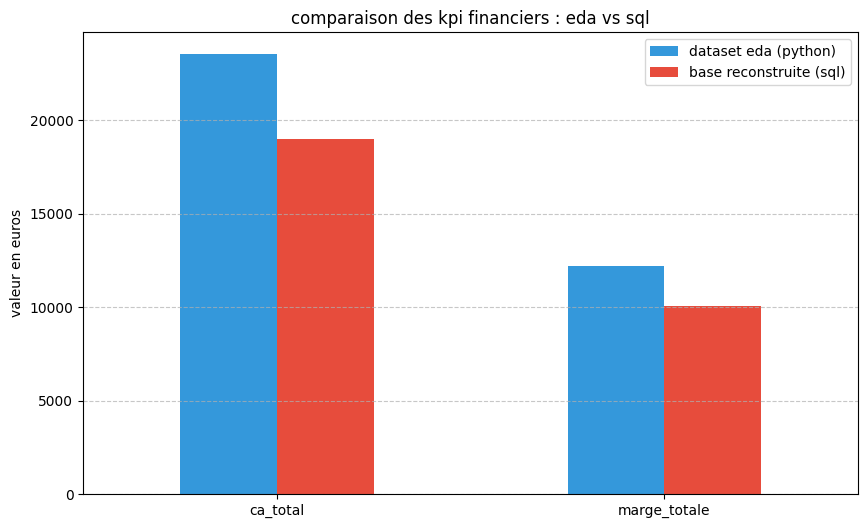

In [11]:
# On prepare les donnees pour le graphique (on exclut les taux pour garder des echelles comparables)
kpis_financiers = ['ca_total', 'marge_totale']
df_visu = df_test_final.loc[kpis_financiers, ['eda_python', 'sql_reconstruit']]

# Creation du graphique en barres
df_visu.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c'])
plt.title("comparaison des kpi financiers : eda vs sql")
plt.ylabel("valeur en euros")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(["dataset eda (python)", "base reconstruite (sql)"])
plt.show()

In [12]:
# Seuil de tolerance (souvent 1% en entreprise)
seuil = 1.0 

# Verification du ca (l'indicateur le plus critique)
ecart_ca = abs(df_test_final.loc['ca_total', 'delta_relatif_%'])

print("Résulat")
if ecart_ca < seuil:
    print(f"Validation reussie : l'ecart est de {ecart_ca:.2f}%.")
    print("La base reconstruite est fiable pour alimenter Power BI.")
else:
    print(f"Alerte : l'ecart est de {ecart_ca:.2f}%.")
    print("Attention : la base SQL ne correspond pas au perimetre de l'EDA.")

Résulat
Alerte : l'ecart est de 19.25%.
Attention : la base SQL ne correspond pas au perimetre de l'EDA.


In [13]:
# Dictionnaire des kpi SQL obtenus sur bigquery entre 2023 et 2024
stats_sql_officiel = {
    2023: {
        'ca': 7496.180004119873, 
        'marge': 3983.3351309010836, 
        'aov': 102.68739731671059, 
        'tx_retour': 0.0998185117967332,
        'tx_reachat': 0.0
    },
    2024: {
        'ca': 11497.600009918213, 
        'marge': 6071.2850773775654, 
        'aov': 78.2149660538654,
        'tx_retour': 0.091836734693877556,
        'tx_reachat': 0.043165467625899283

    }
}

In [14]:
def kpi_complets_par_annee(df):
    df['year'] = df['item_date'].dt.year
    resultats = {}
    
    for annee in [2023, 2024]:
        data_annee = df[df['year'] == annee]
        ventes = data_annee[data_annee['status'].str.lower() == 'complete']
        retours = data_annee[data_annee['status'].str.lower() == 'returned']
        
        # ca et marge
        ca = ventes['sale_price'].sum()
        marge = (ventes['sale_price'] - ventes['cost']).sum()
        
        # panier moyen (aov)
        nb_cmd = ventes['order_id'].nunique()
        aov = ca / nb_cmd if nb_cmd > 0 else 0
        
        # taux de retour
        tx_retour = len(retours) / (len(ventes) + len(retours)) if (len(ventes) + len(retours)) > 0 else 0
        
        # taux de ré-achat
        cmd_par_client = ventes.groupby('user_id')['order_id'].nunique()
        tx_reachat = (cmd_par_client >= 2).sum() / ventes['user_id'].nunique() if ventes['user_id'].nunique() > 0 else 0
        
        resultats[annee] = {
            'ca': ca, 
            'marge': marge, 
            'aov': aov, 
            'tx_retour': tx_retour, 
            'tx_reachat': tx_reachat
        }
    return resultats

# exécution
kpi_eda = kpi_complets_par_annee(df_eda)
kpi_sql_extract = kpi_complets_par_annee(df_sql)

In [15]:
comparaison_rows = []

for annee in [2023, 2024]:
    for metrique in ['ca', 'marge', 'aov', 'tx_retour', 'tx_reachat']:
        comparaison_rows.append({
            'annee': annee,
            'metrique': metrique,
            'eda_python': kpi_eda[annee][metrique],
            'sql_extraction': kpi_sql_extract[annee][metrique],
            'sql_officiel': stats_sql_officiel[annee][metrique]
        })

df_final_check = pd.DataFrame(comparaison_rows)

# Calcul de l'écart relatif entre le csv initial et tes requêtes sql
df_final_check['diff_pourcent'] = (
    (df_final_check['eda_python'] - df_final_check['sql_officiel']) / df_final_check['sql_officiel'] * 100
)

print("Validation de la cohérence annuelle totale")
display(df_final_check.round(3))

Validation de la cohérence annuelle totale


,annee,metrique,eda_python,sql_extraction,sql_officiel,diff_pourcent
0,2023,ca,7806.320,7496.180,7496.180,4.137
1,2023,marge,4075.344,3983.335,3983.335,2.310
2,2023,aov,80.478,102.687,102.687,-21.629
3,2023,tx_retour,0.379,0.324,0.100,279.412
4,2023,tx_reachat,0.000,0.000,0.000,NaN
5,2024,ca,15716.280,11497.600,11497.600,36.692
6,2024,marge,8134.606,6071.285,6071.285,33.985
7,2024,aov,85.415,78.215,78.215,9.205
8,2024,tx_retour,0.304,0.266,0.092,231.283
9,2024,tx_reachat,0.034,0.043,0.043,-21.469
